# Lick Analysis For Single Mouse - Operand Conditioning

In [1]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import joypy

%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

<Figure size 432x288 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

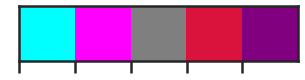

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

# Define the main functions first

In [4]:
def fun_1(objs):
    #load data and extract lick times
    rew_time_ls = []
    rew2_time_ls = []
    unrew_time_ls = []
    miss_ls= []
    for idx, x in enumerate(objs):
        if overall_order[idx] == '0':
            try:
                rew_time_ls.append(x.split("r")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])
        elif overall_order[idx] == '1':
            try:
                rew2_time_ls.append(x.split("z")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])            
        elif overall_order[idx] == '2':
            try:
                unrew_time_ls.append(x.split("o")[1].split(" ")[0].split("u")[0])
            except:
                print("Error{0}".format(idx))

#     print(len(rew_time_ls))
#     print(len(rew2_time_ls))
#     print(len(unrew_time_ls))
#     print(len(miss_ls))
    
#     total_trials = len(rew_time_ls)+len(rew2_time_ls)+len(unrew_time_ls)+len(miss_ls)
#     print(total_trials)
    
    return rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls

In [5]:
def fun_2(objs, rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls):
    #converting the string to an array
    rew_time_ar = np.array(rew_time_ls, dtype=np.float32)
    rew2_time_ar = np.array(rew2_time_ls, dtype=np.float32)
    unrew_time_ar = np.array(unrew_time_ls, dtype=np.float32)
    miss_time_ar = np.array(miss_ls, dtype=np.float32)

    #subtracting the stimulus duration
    rew_times = rew_time_ar - inter_dur
    rew2_times = rew2_time_ar - inter_dur
    unrew_times = unrew_time_ar - inter_dur
    miss_times = miss_time_ar - inter_dur

    #removing the 'u', 'r', 'z', 'o' and 'm' identifiers
    cleaned_objs = [ x.replace('u', ' ') for x in objs if 'u' in x ]

    rew_cleaned = [ x.replace('r',' ') for x in cleaned_objs if 'r' in x ]
    rew2_cleaned = [ x.replace('z',' ') for x in cleaned_objs if 'z' in x ]
    unrew_cleaned = [ x.replace('o',' ') for x in cleaned_objs if 'o' in x ]
    miss_cleaned = [ x.replace('m',' ') for x in cleaned_objs if 'm' in x]
    
    rew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew_cleaned ]
    rew2_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew2_cleaned ]
    unrew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in unrew_cleaned ]
    miss_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in miss_cleaned ]

    for idx, val in enumerate(rew_time_ar):
        rew_lick[idx] =  rew_lick[idx][rew_lick[idx] != val]
    for idx, val in enumerate(rew2_time_ar):
        rew2_lick[idx] =  rew2_lick[idx][rew2_lick[idx] != val]
    for idx, val in enumerate(unrew_time_ar):
        unrew_lick[idx] =  unrew_lick[idx][unrew_lick[idx] != val]
    for idx, val in enumerate(miss_time_ar):
        miss_lick[idx] = miss_lick[idx][miss_lick[idx] != val]
        
    # Create data frame for the rewarded - water - trials
    rew_df = pd.DataFrame(rew_lick).sub(rew_times, axis = 0)
    num_rew_tr = rew_df.shape[0]
    # Create data frame for the rewarded - no water - trials
    rew2_df = pd.DataFrame(rew2_lick).sub(rew2_times, axis = 0)
    num_rew2_tr = rew2_df.shape[0]
    # Create data frame for the unrewarded trials
    unrew_df = pd.DataFrame(unrew_lick).sub(unrew_times, axis = 0)
    num_unrew_tr = unrew_df.shape[0]
    # Create a data frame for the rewarded trials that had no licks during stim time
    miss_df = pd.DataFrame(miss_lick).sub(miss_times, axis = 0)
    num_miss_tr = miss_df.shape[0]

    df_licks = pd.concat([rew_df, rew2_df, miss_df, unrew_df], ignore_index=True) # the order here is important
    df_licks.drop(df_licks.index[0], inplace=True)
    df_licks2 = pd.DataFrame(df_licks.stack())
    
    return df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr



In [6]:
def fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr):
    test = df_licks.to_numpy()

    list_of_licks_per_trial = []
    counter = 0
    for i in range(num_rew_tr+num_rew2_tr+num_unrew_tr+num_miss_tr-1):
        for value in test[i]:
            if value > -100000000 and value < 10000000:
                counter += 1
            else:
                break
        list_of_licks_per_trial.append(counter)
        counter = 0 
#     print(len(list_of_licks_per_trial))
#     print(list_of_licks_per_trial)

    list_reward_and_none = []
    for i, value in enumerate(list_of_licks_per_trial):
        for j in range(value):
            if i < num_rew_tr:       # Check if it's less than or less than or equal
                list_reward_and_none.append("rew")
            elif i > num_rew_tr and i < (num_rew_tr+num_rew2_tr):
                list_reward_and_none.append("rew2")
            elif i > (num_rew_tr+num_rew2_tr) and i < (num_rew_tr+num_rew2_tr+num_miss_tr):
                list_reward_and_none.append("miss")
            else:
                list_reward_and_none.append("unrew")
    
    df_licks2 = df_licks2.reset_index()
    df_licks2.columns = ["trial", "lick_idx", "lick_time"]

    df_licks2["stim id"] = list_reward_and_none
    
#     print(df_licks2["stim id"].unique())
    
    return df_licks2

# Define universal variables first

In [7]:
# u = start of trial
# m = no licks
# r = timestamp of reward
# z = rew2 stimulus
# o = unrew stimulus
# r, z, and o happen 1 sec after the stimulus ends

interval = 1.0
stim_dur = 0.2
inter_dur = interval+stim_dur

In [8]:
#Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
               0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
               0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
               0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
               1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
               0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

#Psuedo random distribution of water to the rewarded stimuli
# 0 -- water given -- 80 times
# 1 -- no water given -- 20 times
rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
               0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
               0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
               0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

In [9]:
overall_order = []
i=0
for idx,val in enumerate(stim_order):
    if val == 0:
        i = i+1
        if rew_order[i-1] == 0:
            overall_order.append('0') # rewH20
        elif rew_order[i-1] == 1:
            overall_order.append('1') # rewnoH20
    elif val == 1:
        overall_order.append('2')     # unrew
print(len(overall_order))

150


# Main Function - single mouse
Uses the defined path to load the .pkl files, extract and normalize the lick times, and organize it into a dataframe

In [152]:
#load data of single mouse (one WT and one FX)

# WT_path = r"U:\Data\zimmer94\Behavior\licks\07.30.21\CC082260_HP3_oper_disc_2021-07-30_12-53-30.pkl"
# FX_path = r"U:\Data\zimmer94\Behavior\licks\07.30.21\CC067432_HP2_oper_disc_2021-07-30_13-27-56.pkl"

WT_path = r"D:\mz_Data\RECORDING_DATA\lick_data\oper_rec_licks\CC082263_HP1_RecInter_2021-08-12_11-22-51.pkl"
FX_path = r"D:\mz_Data\RECORDING_DATA\lick_data\oper_rec_licks\CC082255_HP0_RecInter_2021-08-27_13-26-57.pkl"


In [153]:
f=open(WT_path, 'rb')
WT_objs = []
while 1:
    try:
        WT_objs.append(pickle.load(f))
    except EOFError:
        break
f.close()

f=open(FX_path, 'rb')
FX_objs = []
while 1:
    try:
        FX_objs.append(pickle.load(f))
    except EOFError:
        break
f.close()

In [154]:
rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(WT_objs)

df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(WT_objs,
                                                                                rew_time_ls, 
                                                                                rew2_time_ls,
                                                                                unrew_time_ls, 
                                                                                miss_ls)

WT_df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)

In [155]:
rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(FX_objs)

df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(FX_objs,
                                                                                rew_time_ls, 
                                                                                rew2_time_ls,
                                                                                unrew_time_ls, 
                                                                                miss_ls)

FX_df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)

# Identify the groups with a label

In [156]:
def get_cc(path):
    cc = path.split('/')[-1].split('_')[0]
    hp = path.split('/')[-1].split('_')[1]
    combo = cc+hp
    
    return cc, combo

In [157]:
stim_lb = 0.0 #lower bound of stimulus time
stim_ub = 0.2 #upper bound of stimulus time
rew_lb = stim_ub+1.0
rew_ub = stim_ub+1.0+0.1

wt_cc, wt_et = get_cc(WT_path)
fx_cc, fx_et = get_cc(FX_path)

WT_df_licks2['group'] = 'WT'
FX_df_licks2['group'] = 'FX'

# Isolate by situation

In [158]:
wt_rew_df = WT_df_licks2[WT_df_licks2['stim id'] == 'rew']
wt_rew2_df = WT_df_licks2[WT_df_licks2['stim id'] == 'rew2']
wt_miss_df = WT_df_licks2[WT_df_licks2['stim id'] == 'miss']
wt_unrew_df = WT_df_licks2[WT_df_licks2['stim id'] == 'unrew']

In [159]:
fx_rew_df = FX_df_licks2[FX_df_licks2['stim id'] == 'rew']
fx_rew2_df = FX_df_licks2[FX_df_licks2['stim id'] == 'rew2']
fx_miss_df = FX_df_licks2[FX_df_licks2['stim id'] == 'miss']
fx_unrew_df = FX_df_licks2[FX_df_licks2['stim id'] == 'unrew']

In [160]:
# print('rew: {}'.format(wt_rew_df.trial.unique()))
# print('rew2: {}'.format(wt_rew2_df.trial.unique()))
# print('miss: {}'.format(wt_miss_df.trial.unique()))
# print('unrew: {}'.format(wt_unrew_df.trial.unique()))

In [161]:
# print('rew: {}'.format(fx_rew_df.trial.unique()))
# print('rew2: {}'.format(fx_rew2_df.trial.unique()))
# print('miss: {}'.format(fx_miss_df.trial.unique()))
# print('unrew: {}'.format(fx_unrew_df.trial.unique()))

# Plot all trials in the situation

Text(60.5, 0.5, 'Trial #')

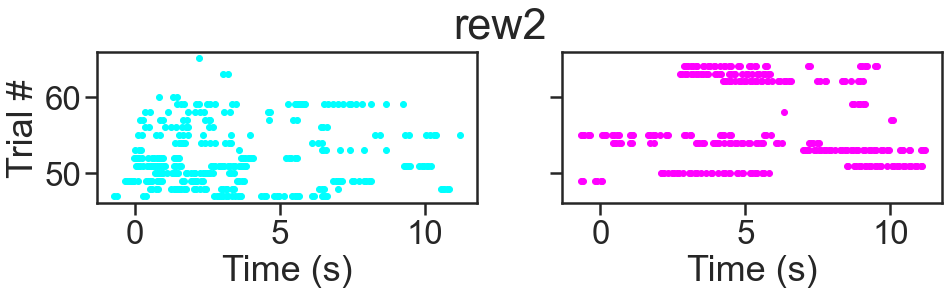

In [162]:
x1 = wt_rew2_df.lick_time.values
y1 = wt_rew2_df.trial
x2 = fx_rew2_df.lick_time.values
y2 = fx_rew2_df.trial

plt_title = 'rew2'


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
fig.tight_layout()
plt.suptitle(plt_title)

ax1.plot(x1,y1, '.', color='cyan')
ax2.plot(x2,y2, '.', color='magenta')

ax1.set_xlabel('Time (s)')
ax2.set_xlabel('Time (s)')
ax1.set_ylabel('Trial #')

# Re-index the trial numbers

In [163]:
wt_rew_df['trial'] -= wt_rew_df.trial.values[0]
wt_rew2_df['trial'] -= wt_rew2_df.trial.values[0]
# wt_miss_df['trial'] -= wt_miss_df.trial.values[0]
wt_unrew_df['trial'] -= wt_unrew_df.trial.values[0]

<ipython-input-163-4c72c398fd05>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wt_rew_df['trial'] -= wt_rew_df.trial.values[0]
<ipython-input-163-4c72c398fd05>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wt_rew2_df['trial'] -= wt_rew2_df.trial.values[0]
<ipython-input-163-4c72c398fd05>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [164]:
fx_rew_df['trial'] -= fx_rew_df.trial.values[0]
fx_rew2_df['trial'] -= fx_rew2_df.trial.values[0]
fx_miss_df['trial'] -= fx_miss_df.trial.values[0]
fx_unrew_df['trial'] -= fx_unrew_df.trial.values[0]

<ipython-input-164-e73cd6a8cf4b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx_rew_df['trial'] -= fx_rew_df.trial.values[0]
<ipython-input-164-e73cd6a8cf4b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx_rew2_df['trial'] -= fx_rew2_df.trial.values[0]
<ipython-input-164-e73cd6a8cf4b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [165]:
print('rew: {}'.format(wt_rew_df.trial.unique()))
print('rew2: {}'.format(wt_rew2_df.trial.unique()))
print('miss: {}'.format(wt_miss_df.trial.unique()))
print('unrew: {}'.format(wt_unrew_df.trial.unique()))

rew: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]
rew2: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 16 18]
miss: [75 76 77 78 79 80 81 82 83]
unrew: [ 0  1  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]


In [166]:
print('rew: {}'.format(fx_rew_df.trial.unique()))
print('rew2: {}'.format(fx_rew2_df.trial.unique()))
print('miss: {}'.format(fx_miss_df.trial.unique()))
print('unrew: {}'.format(fx_unrew_df.trial.unique()))

rew: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]
rew2: [ 0  1  2  4  5  6  8  9 10 13 14 15]
miss: [ 0  7  8  9 12 14 15 18 19 20 21 30 33 34]
unrew: [  0  20  56  57  58  59  60  62  69  70  73  74  75  76  77  78  79  80
  82  85  87  91  92  93  94  96  98  99 100 102 103]


# Manual additional refinement

In [167]:
# final refinement of the trial numbers!
wt_unrew_df['trial'] -= 20
fx_unrew_df['trial'] -= 30

<ipython-input-167-87ad50a18d6e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wt_unrew_df['trial'] -= 20
<ipython-input-167-87ad50a18d6e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx_unrew_df['trial'] -= 30


# Combine the WT & FX dataframes

In [168]:
combo_df = pd.concat([WT_df_licks2,FX_df_licks2])

rew_df = pd.concat([wt_rew_df, fx_rew_df])
rew2_df = pd.concat([wt_rew2_df, fx_rew2_df])
miss_df = pd.concat([wt_miss_df, fx_miss_df])
unrew_df = pd.concat([wt_unrew_df, fx_unrew_df])


# Only take a look at the first 15 trials in each group
This is also where you choose what situation to look at (rew, rew2, unrew, miss)

In [169]:
reward_input = input('Situation (rew, rew2, miss, unrew): ')

if reward_input == 'rew':
    first_trials = rew_df[(rew_df['trial'] >= 0) & (rew_df['trial'] <= 15)]
    wt_data = first_trials[first_trials['group'] == 'WT']
    fx_data = first_trials[first_trials['group'] == 'FX']
    combined = first_trials
    plt_title = 'Rewarded with Water'
elif reward_input == 'rew2':
    first_trials = rew2_df[(rew2_df['trial'] >= 0) & (rew2_df['trial'] <= 15)]
    wt_data = first_trials[first_trials['group'] == 'WT']
    fx_data = first_trials[first_trials['group'] == 'FX']
    combined = first_trials
    plt_title = 'Rewarded without Water'
elif reward_input == 'miss':
    first_trials = miss_df[(miss_df['trial'] >= 0) & (miss_df['trial'] <= 15)]
    wt_data = first_trials[first_trials['group'] == 'WT']
    fx_data = first_trials[first_trials['group'] == 'FX']
    combined = first_trials
    plt_title = 'Miss'
elif reward_input == 'unrew':
    first_trials = unrew_df[(unrew_df['trial'] >= 0) & (unrew_df['trial'] <= 15)]
    wt_data = first_trials[first_trials['group'] == 'WT']
    fx_data = first_trials[first_trials['group'] == 'FX']
    combined = first_trials
    plt_title = 'Unrewarded'
else:
    raise ValueError('Incorrect input, try again...')

Situation (rew, rew2, miss, unrew): rew2


# Now I can start plotting things

In [170]:
xticks = [0,2,4,6,8]
xlim = [-1,9]

In [171]:
x1 = wt_data.lick_time.values
y1 = wt_data.trial

x2 = fx_data.lick_time.values
y2 = fx_data.trial

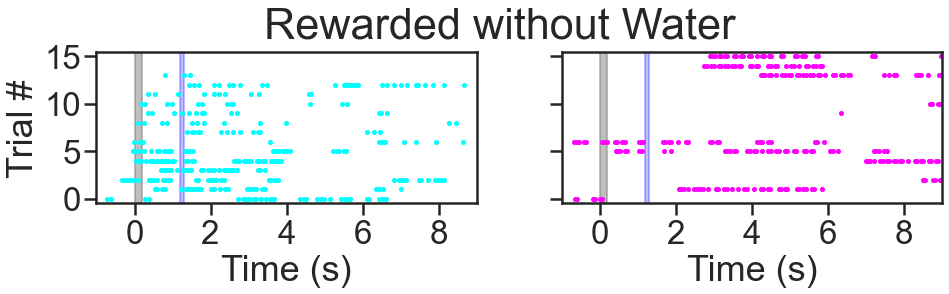

In [173]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
fig.tight_layout()
plt.suptitle(plt_title)

ax1.plot(x1,y1, '.', color='cyan', markersize=8)
ax2.plot(x2,y2, '.', color='magenta', markersize=8)

plt.xticks(xticks)
plt.xlim(xlim)
plt.ylim([-0.5,15.5])
plt.yticks([0,5,10,15])

ax1.axvspan(stim_lb,stim_ub, color='grey', alpha=0.5)
ax1.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 
ax2.axvspan(stim_lb,stim_ub, color='grey', alpha=0.5)
ax2.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 

ax1.set_xlabel('Time (s)')
ax2.set_xlabel('Time (s)')
ax1.set_ylabel('Trial #')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\trained\raster_rew2.pdf", transparent=True)

plt.show()

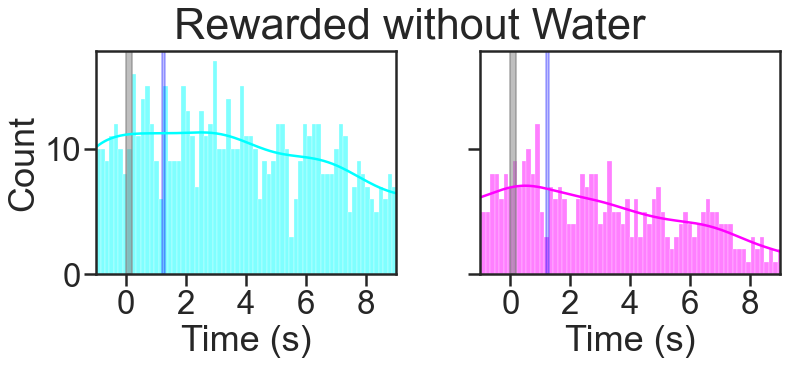

In [134]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
fig.tight_layout()
plt.suptitle(plt_title)

sns.histplot(data=wt_data, 
             x='lick_time', 
             binwidth = 0.15,
             stat='count',
             color='cyan',
             kde=True,
             ax=ax1
            )

sns.histplot(data=fx_data, 
             x='lick_time', 
             binwidth = 0.15,
             stat='count',
             color='magenta',
             kde=True,
             ax=ax2
            )

ax1.set_xlabel('Time (s)')
ax2.set_xlabel('Time (s)')

ax1.axvspan(stim_lb,stim_ub, color='grey', alpha=0.5)
ax1.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 
ax2.axvspan(stim_lb,stim_ub, color='grey', alpha=0.5)
ax2.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 

plt.xlim(xlim)
plt.xticks(xticks)
# plt.ylim([0,0.3])

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\untrained\hist_rew2.pdf", transparent=True)

plt.show()

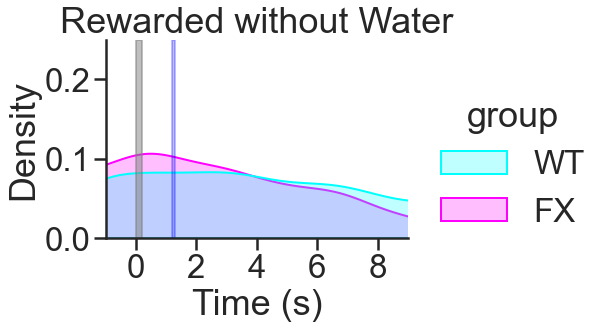

In [136]:
sns.displot(combined, x='lick_time', 
            hue="group", 
            kind="kde", 
            common_norm=False, 
#             rug=True,
            fill = True,
            height=5, 
            aspect=1.4
           )

plt.title(plt_title)
plt.xlim(xlim)
plt.xticks(xticks)
plt.xlabel('Time (s)')

plt.ylim([0,0.25])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.5)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 


# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\untrained\kde_rew2.pdf", transparent=True)

plt.show()

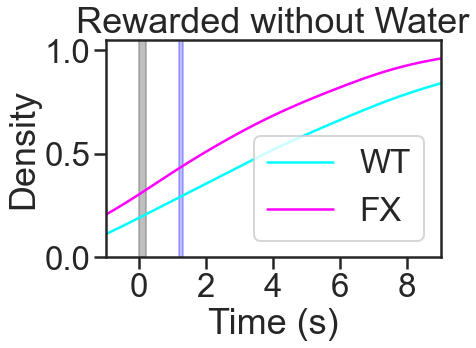

In [138]:
x1 = wt_data.lick_time.values
x2 = fx_data.lick_time.values

sns.kdeplot(x1, 
            cumulative=True, 
            color = 'cyan', 
            label='WT')
sns.kdeplot(x2, 
            cumulative=True, 
            color = 'magenta', 
            label='FX')

plt.title(plt_title)
plt.xlim(xlim)
plt.xticks(xticks)
plt.xlabel('Time (s)')

plt.legend(loc='lower right')

plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.5)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\untrained\cs_rew2.pdf", transparent=True)

plt.show()